In [2]:
# import and setup
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the duckdb
con = duckdb.connect('../data/sakila.duckdb')

print("✅ Connected to Sakila database!")
print(f"DuckDB version: {duckdb.__version__}")

# Show available tables
tables = con.execute("SHOW TABLES").fetchdf()
print(f"\nAvailable tables ({len(tables)}):")
print(tables)

✅ Connected to Sakila database!
DuckDB version: 1.4.3

Available tables (16):
             name
0           actor
1         address
2        category
3            city
4         country
5        customer
6            film
7      film_actor
8   film_category
9       film_text
10      inventory
11       language
12        payment
13         rental
14          staff
15          store


In [3]:
# Task 1a: Movies longer than 3 hours (180 minutes)

query = """
SELECT 
    title, 
    length
FROM film
WHERE length > 180
ORDER BY length DESC;
"""

df_long_movies = con.execute(query).fetchdf()

print(f"Found {len(df_long_movies)} movies longer than 180 minutes:\n")
display(df_long_movies)

Found 39 movies longer than 180 minutes:



,title,length
0,WORST BANGER,185
1,CHICAGO NORTH,185
2,CONTROL ANTHEM,185
3,DARN FORRESTER,185
4,SWEET BROTHERHOOD,185
5,GANGS PRIDE,185
6,HOME PITY,185
7,SOLDIERS EVOLUTION,185
8,POND SEATTLE,185
9,MUSCLE BRIGHT,185


In [4]:
# Task 1b: Movies with "love" in title

query = """
SELECT 
    title,
    rating,
    length,
    description
FROM film
WHERE title LIKE '%love%'
OR title LIKE '%Love%'
OR title LIKE '%LOVE%'
ORDER BY title;
"""

df_love_movies = con.execute(query).fetchdf()

print(f"Found {len(df_love_movies)} movies with 'love' in the title:\n")
display(df_love_movies)

Found 10 movies with 'love' in the title:



,title,rating,length,description
0,GRAFFITI LOVE,PG,117,A Unbelieveable Epistle of a Sumo Wrestler And...
1,IDAHO LOVE,PG-13,172,A Fast-Paced Drama of a Student And a Crocodil...
2,IDENTITY LOVER,PG-13,119,A Boring Tale of a Composer And a Mad Cow who ...
3,INDIAN LOVE,NC-17,135,A Insightful Saga of a Mad Scientist And a Mad...
4,LAWRENCE LOVE,NC-17,175,A Fanciful Yarn of a Database Administrator An...
5,LOVE SUICIDES,R,181,A Brilliant Panorama of a Hunter And a Explore...
6,LOVELY JINGLE,PG,65,A Fanciful Yarn of a Crocodile And a Forensic ...
7,LOVER TRUMAN,G,75,A Emotional Yarn of a Robot And a Boy who must...
8,LOVERBOY ATTACKS,PG-13,162,A Boring Story of a Car And a Butler who must ...
9,STRANGELOVE DESIRE,NC-17,103,A Awe-Inspiring Panorama of a Lumberjack And a...


In [ ]:
# Task 1c: Descriptive statistics on movie length

query = """
SELECT 
    MIN(length) as shortest,
    AVG(length) as average,
    MEDIAN(length) as median,
    MAX(length) as longest
FROM film;
"""

df_stats = con.execute(query).fetchdf()

print("Movie length statistics (in minutes):\n")
display(df_stats)

print(f"""
Movie Length Statistics:
- Shortest: {df_stats['shortest'].iloc[0]} minutes
- Average: {df_stats['average'].iloc[0]:.2f} minutes
- Median: {df_stats['median'].iloc[0]} minutes
- Longest: {df_stats['longest'].iloc[0]} minutes
""")

Movie length statistics (in minutes):



,shortest,average,median,longest
0,46,115.272,114.0,185



Movie Length Statistics:
- Shortest: 46 minutes
- Average: 115.27 minutes
- Median: 114.0 minutes
- Longest: 185 minutes



In [6]:
# Task 1d: Top 10 most expensive movies to rent per day

query = """
SELECT 
    title,
    rental_rate,
    rental_duration,
    ROUND(rental_rate / rental_duration, 2) as cost_per_day
FROM film
ORDER BY cost_per_day DESC
LIMIT 10;
"""

df_expensive = con.execute(query).fetchdf()

print("Top 10 most expensive movies to rent per day:\n")
display(df_expensive)

Top 10 most expensive movies to rent per day:



,title,rental_rate,rental_duration,cost_per_day
0,ACE GOLDFINGER,4.99,3,1.66
1,AMERICAN CIRCUS,4.99,3,1.66
2,AUTUMN CROW,4.99,3,1.66
3,BACKLASH UNDEFEATED,4.99,3,1.66
4,BEAST HUNCHBACK,4.99,3,1.66
5,BEHAVIOR RUNAWAY,4.99,3,1.66
6,BILKO ANONYMOUS,4.99,3,1.66
7,CARIBBEAN LIBERTY,4.99,3,1.66
8,CASPER DRAGONFLY,4.99,3,1.66
9,CASUALTIES ENCINO,4.99,3,1.66


In [7]:
# Task 1e: Top 10 actors by number of movies

query = """
SELECT 
    a.first_name,
    a.last_name,
    a.first_name || ' ' || a.last_name as full_name,
    COUNT(*) as movie_count
FROM actor a
JOIN film_actor fa ON a.actor_id = fa.actor_id
GROUP BY a.actor_id, a.first_name, a.last_name
ORDER BY movie_count DESC
LIMIT 10;
"""

df_top_actors = con.execute(query).fetchdf()

print("Top 10 actors by number of movies:\n")
display(df_top_actors)

Top 10 actors by number of movies:



,first_name,last_name,full_name,movie_count
0,GINA,DEGENERES,GINA DEGENERES,42
1,WALTER,TORN,WALTER TORN,41
2,MARY,KEITEL,MARY KEITEL,40
3,MATTHEW,CARREY,MATTHEW CARREY,39
4,SANDRA,KILMER,SANDRA KILMER,37
5,SCARLETT,DAMON,SCARLETT DAMON,36
6,HENRY,BERRY,HENRY BERRY,35
7,ANGELA,WITHERSPOON,ANGELA WITHERSPOON,35
8,VIVIEN,BASINGER,VIVIEN BASINGER,35
9,VAL,BOLGER,VAL BOLGER,35


In [ ]:
# Task 1f:  own questions

In [8]:
# Question 1: Which films generate the most revenue?

query = """
SELECT 
    f.title,
    COUNT(r.rental_id) AS times_rented,
    SUM(p.amount) AS total_revenue
FROM film f
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
JOIN payment p ON r.rental_id = p.rental_id
GROUP BY f.film_id, f.title
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_top_revenue = con.execute(query).fetchdf()
print("Top 10 films by revenue:\n")
display(df_top_revenue)

Top 10 films by revenue:



,title,times_rented,total_revenue
0,TELEGRAPH VOYAGE,27,231.73
1,WIFE TURN,31,223.69
2,ZORRO ARK,31,214.69
3,GOODFELLAS SALUTE,31,209.69
4,SATURDAY LAMBS,28,204.72
5,TITANS JERK,29,201.71
6,TORQUE BOUND,27,198.72
7,HARRY IDAHO,30,195.70
8,INNOCENT USUAL,26,191.74
9,HUSTLER PARTY,22,190.78


In [9]:
# Question 2: Which customers are most active?

query = """
SELECT 
    c.first_name,
    c.last_name,
    COUNT(r.rental_id) AS total_rentals
FROM customer c
JOIN rental r ON c.customer_id = r.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_rentals DESC
LIMIT 10;
"""

df_active_customers = con.execute(query).fetchdf()
print("Top 10 most active customers:\n")
display(df_active_customers)

Top 10 most active customers:



,first_name,last_name,total_rentals
0,ELEANOR,HUNT,46
1,KARL,SEAL,45
2,CLARA,SHAW,42
3,MARCIA,DEAN,42
4,TAMMY,SANDERS,41
5,SUE,PETERS,40
6,WESLEY,BULL,40
7,RHONDA,KENNEDY,39
8,TIM,CARY,39
9,MARION,SNYDER,39


In [10]:
# Question 3: Revenue comparison between stores

query = """
SELECT 
    s.store_id,
    COUNT(DISTINCT r.rental_id) AS total_rentals,
    COUNT(DISTINCT c.customer_id) AS total_customers,
    ROUND(SUM(p.amount), 2) AS total_revenue
FROM store s
JOIN staff st ON s.store_id = st.store_id
JOIN payment p ON st.staff_id = p.staff_id
JOIN rental r ON p.rental_id = r.rental_id
JOIN customer c ON r.customer_id = c.customer_id
GROUP BY s.store_id
ORDER BY total_revenue DESC;
"""

df_store_comparison = con.execute(query).fetchdf()
print("Store performance comparison:\n")
display(df_store_comparison)

Store performance comparison:



,store_id,total_rentals,total_customers,total_revenue
0,2,7990,599,33924.06
1,1,8054,599,33482.50


In [11]:
# Question 4: Average time before films are returned

query = """
SELECT 
    ROUND(AVG(EXTRACT(DAY FROM (return_date - rental_date))), 2) AS avg_days_rented,
    MIN(EXTRACT(DAY FROM (return_date - rental_date))) AS min_days,
    MAX(EXTRACT(DAY FROM (return_date - rental_date))) AS max_days
FROM rental
WHERE return_date IS NOT NULL;
"""

df_return_time = con.execute(query).fetchdf()
print("Average rental duration statistics:\n")
display(df_return_time)

Average rental duration statistics:



,avg_days_rented,min_days,max_days
0,4.53,0,9


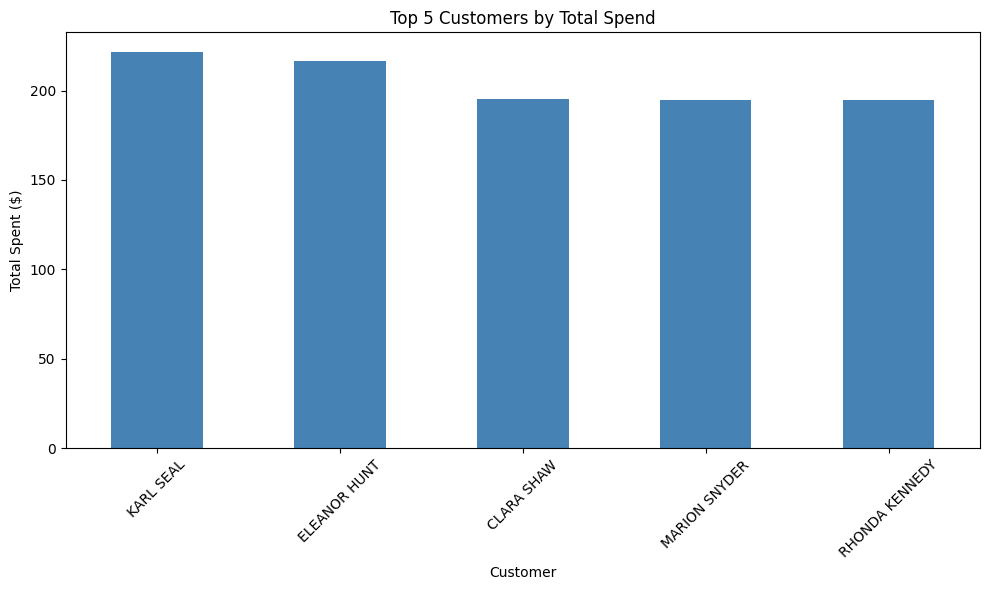

In [13]:
# Task 2a: Top 5 customers by total spend

query = """
SELECT 
    c.first_name || ' ' || c.last_name AS customer_name,
    SUM(p.amount) AS total_spent
FROM customer c
JOIN payment p ON c.customer_id = p.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_spent DESC
LIMIT 5;
"""

df_top_customers = con.execute(query).fetchdf()

# Bar chart
df_top_customers.plot(kind='bar', x='customer_name', y='total_spent', 
                      figsize=(10, 6), color='steelblue', legend=False)
plt.title('Top 5 Customers by Total Spend')
plt.xlabel('Customer')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

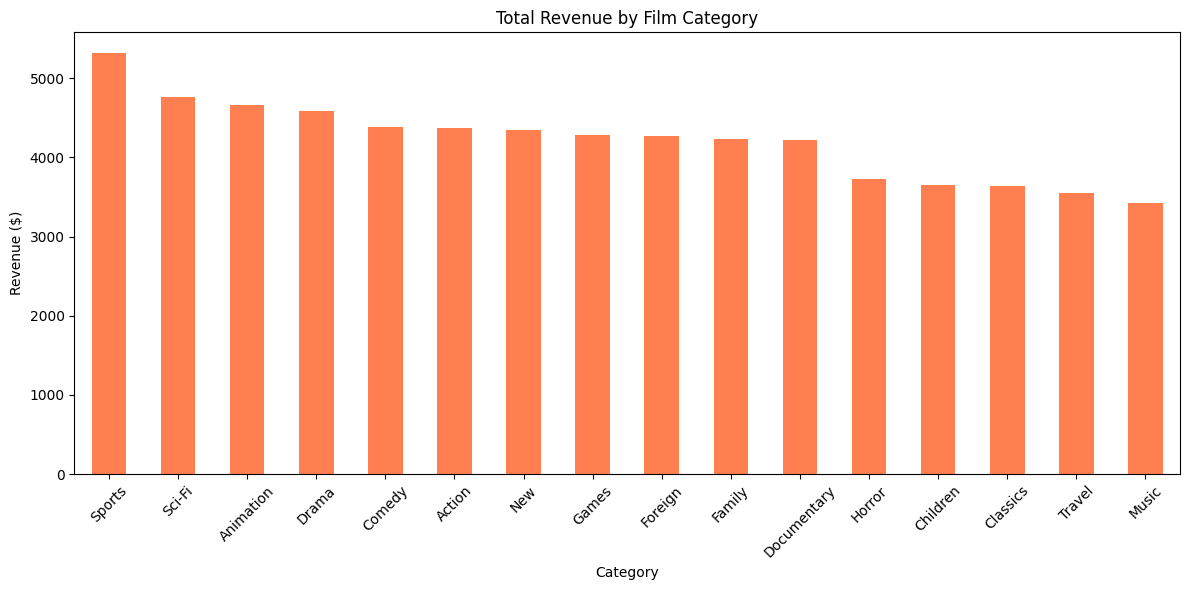

In [14]:
# Task 2b: Revenue per film category

query = """
SELECT 
    c.name AS category,
    ROUND(SUM(p.amount), 2) AS total_revenue
FROM category c
JOIN film_category fc ON c.category_id = fc.category_id
JOIN film f ON fc.film_id = f.film_id
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
JOIN payment p ON r.rental_id = p.rental_id
GROUP BY c.category_id, c.name
ORDER BY total_revenue DESC;
"""

df_category_revenue = con.execute(query).fetchdf()

# Bar chart
df_category_revenue.plot(kind='bar', x='category', y='total_revenue',
                         figsize=(12, 6), color='coral', legend=False)
plt.title('Total Revenue by Film Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()